In [ ]:
# Parte 1: Árvore de Decisão
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dados de Treino: {X_train.shape[0]} amostras")
print(f"Dados de Teste: {X_test.shape[0]} amostras")

Dados de Treino: 124 amostras
Dados de Teste: 54 amostras


In [ ]:
modelo_arvore = DecisionTreeClassifier(max_depth=3, random_state=42)

modelo_arvore.fit(X_train, y_train)

print("Árvore de Decisão treinada com sucesso!")

Árvore de Decisão treinada com sucesso!


Acurácia da Árvore de Decisão: 96.30%

Relatório de Classificação:
              precision    recall  f1-score   support

     class_0       1.00      0.95      0.97        19
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



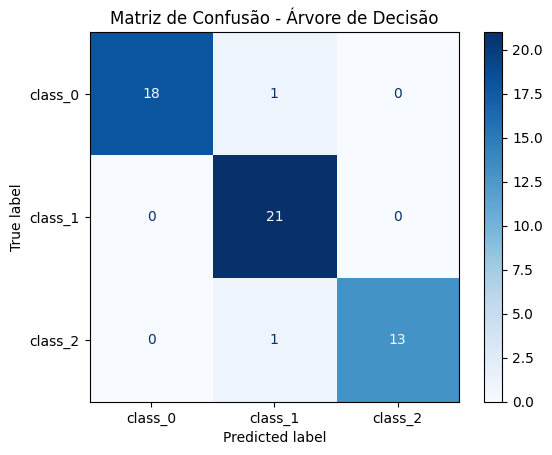

In [ ]:
y_pred_arvore = modelo_arvore.predict(X_test)

acuracia_arvore = accuracy_score(y_test, y_pred_arvore)
print(f"Acurácia da Árvore de Decisão: {acuracia_arvore:.2%}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_arvore, target_names=wine.target_names))

cm = confusion_matrix(y_test, y_pred_arvore)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

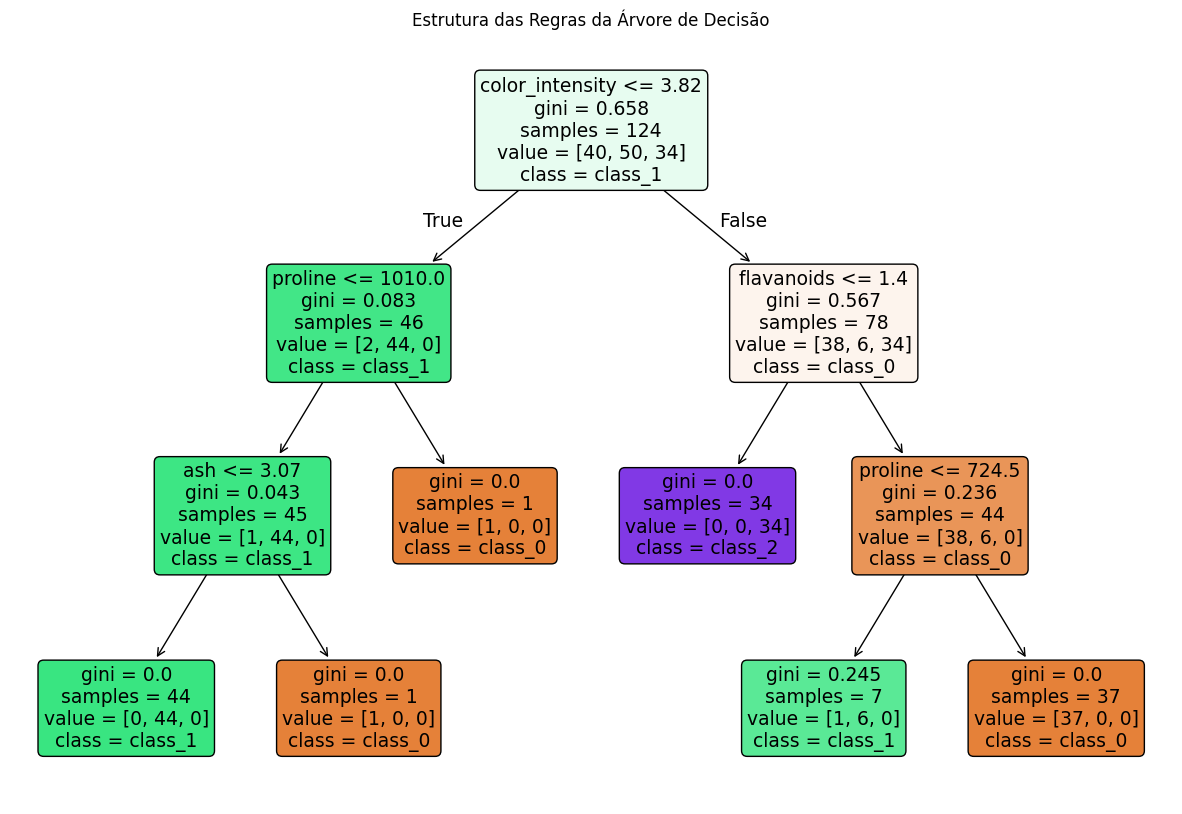

In [ ]:
plt.figure(figsize=(15,10))
plot_tree(modelo_arvore,
          feature_names=wine.feature_names,
          class_names=wine.target_names,
          filled=True,
          rounded=True)
plt.title("Estrutura das Regras da Árvore de Decisão")
plt.show()

In [ ]:
# Parte 2: MLP (Redes Neurais)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados normalizados com sucesso!")

Dados normalizados com sucesso!


In [ ]:
from sklearn.neural_network import MLPClassifier

modelo_mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=500, random_state=42)

modelo_mlp.fit(X_train_scaled, y_train)

print("Rede Neural MLP treinada com sucesso!")

Rede Neural MLP treinada com sucesso!


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Acurácia da Rede Neural MLP: 98.15%

Relatório de Classificação (MLP):
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



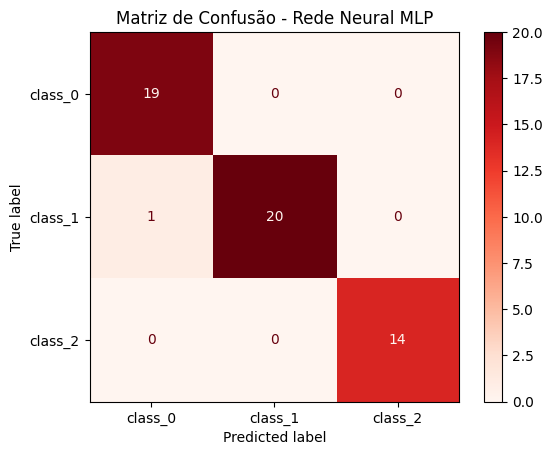

In [ ]:
y_pred_mlp = modelo_mlp.predict(X_test_scaled)

acuracia_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Acurácia da Rede Neural MLP: {acuracia_mlp:.2%}\n")

print("Relatório de Classificação (MLP):")
print(classification_report(y_test, y_pred_mlp, target_names=wine.target_names))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=wine.target_names)
disp_mlp.plot(cmap=plt.cm.Reds)
plt.title("Matriz de Confusão - Rede Neural MLP")
plt.show()

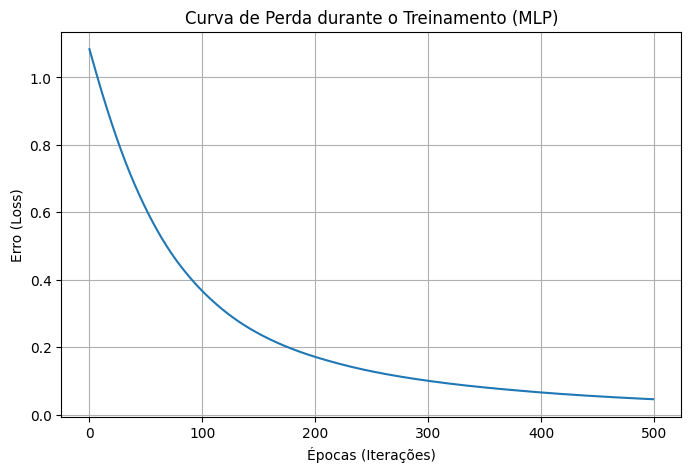

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(modelo_mlp.loss_curve_)
plt.title("Curva de Perda durante o Treinamento (MLP)")
plt.xlabel("Épocas (Iterações)")
plt.ylabel("Erro (Loss)")
plt.grid(True)
plt.show()

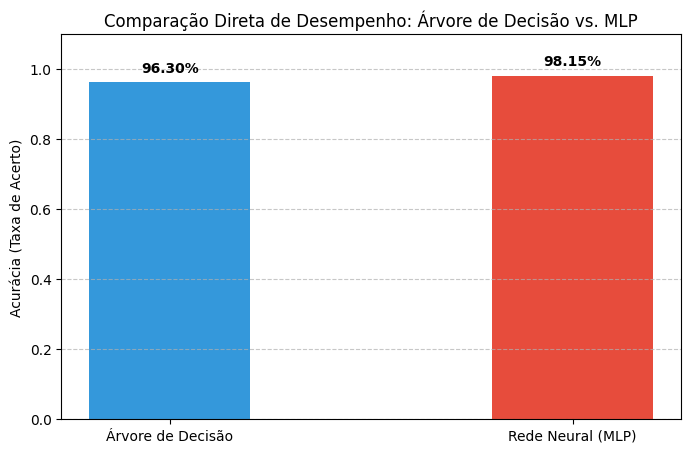

In [ ]:
# Parte Final: Comparação do desempenho entre os dois modelos
import numpy as np

modelos = ['Árvore de Decisão', 'Rede Neural (MLP)']
acuracias = [acuracia_arvore, acuracia_mlp]

plt.figure(figsize=(8, 5))
cores = ['#3498db', '#e74c3c']
barras = plt.bar(modelos, acuracias, color=cores, width=0.4)

plt.ylim(0, 1.1)
plt.ylabel('Acurácia (Taxa de Acerto)')
plt.title('Comparação Direta de Desempenho: Árvore de Decisão vs. MLP')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2.0, yval + 0.02, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.show()